Single KNN Accuracy: 0.7770
Bagging KNN Accuracy: 0.7922

Classification Report - Bagging KNN:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      7009
           1       0.55      0.35      0.43      1991

    accuracy                           0.79      9000
   macro avg       0.69      0.63      0.65      9000
weighted avg       0.77      0.79      0.77      9000



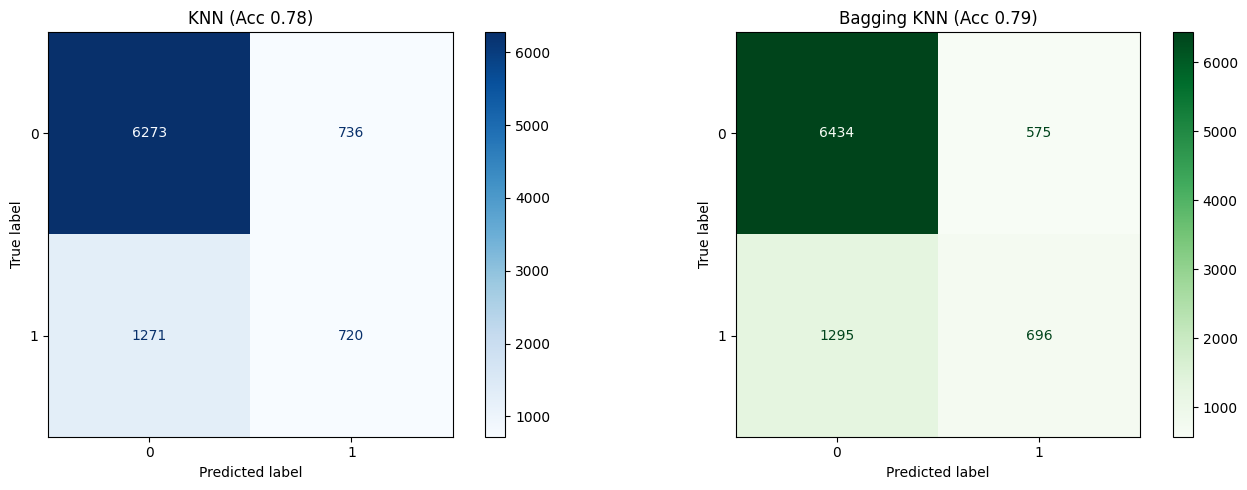

'Output -\nSingle KNN Accuracy: 0.7770\nBagging KNN Accuracy: 0.7923\nClassification Report - Bagging KNN:\n              precision    recall  f1-score   support\n          0       0.83      0.92      0.87      7009\n          1       0.55      0.35      0.43      1991\n   accuracy                           0.79      9000\n  macro avg       0.69      0.63      0.65      9000\nweighted avg       0.77      0.79      0.77      9000\n'

In [1]:
from sklearn.pipeline import Pipeline
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
# Load dataset
data = fetch_ucirepo(id=350)  # Default of Credit Card Clients
X = data.data.features
y = data.data.targets.iloc[:, 0]  # binary: default or not
# Split
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.3, stratify=y, random_state=42
)
# Preprocess: scale numeric, encode categorical
categorical = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
preproc = ColumnTransformer([
   ('num', StandardScaler(), numerical),
   ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
# Pipelines
knn_pipe = Pipeline([
   ('pre', preproc),
   ('model', KNeighborsClassifier(n_neighbors=3))
])
bag_pipe = Pipeline([
   ('pre', preproc),
   ('model', BaggingClassifier(
       estimator=KNeighborsClassifier(n_neighbors=3),
       n_estimators=100,
       max_samples=0.8,
       bootstrap=True,
       random_state=42,
       n_jobs=-1
   ))
])
# Train and evaluate
knn_pipe.fit(X_train, y_train)
bag_pipe.fit(X_train, y_train)
y_knn = knn_pipe.predict(X_test)
y_bag = bag_pipe.predict(X_test)
acc_knn = accuracy_score(y_test, y_knn)
acc_bag = accuracy_score(y_test, y_bag)
print(f"Single KNN Accuracy: {acc_knn:.4f}")
print(f"Bagging KNN Accuracy: {acc_bag:.4f}")
print("\nClassification Report - Bagging KNN:\n", classification_report(y_test, y_bag))
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_knn, ax=axes[0], cmap='Blues')
axes[0].set_title(f"KNN (Acc {acc_knn:.2f})")
ConfusionMatrixDisplay.from_predictions(y_test, y_bag, ax=axes[1], cmap='Greens')
axes[1].set_title(f"Bagging KNN (Acc {acc_bag:.2f})")
plt.tight_layout()
plt.show()
'''Output -
Single KNN Accuracy: 0.7770
Bagging KNN Accuracy: 0.7923
Classification Report - Bagging KNN:
              precision    recall  f1-score   support
          0       0.83      0.92      0.87      7009
          1       0.55      0.35      0.43      1991
   accuracy                           0.79      9000
  macro avg       0.69      0.63      0.65      9000
weighted avg       0.77      0.79      0.77      9000
'''